In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numba import njit

# initial value of position, velocisty and mass, in order: sun, earth, moon
r = np.array([[0,0],
             [1.495*10**11, 0],
             [1.495 *10**11, 3.84*10**8]])

v = np.array([[0,0],
             [0, 2.978*10**4],
             [-1.022*10**3, 2.978*10**4]] )
m = np.array([1.98847*(10**30), 5.9772*(10**24), 7.3476*(10**22)])
G =  6.67 *1e-11 

In [2]:
time_step = 60*60  # time step is one hour = 60*60 seconds
position = np.ones([3*365*24, 2*3]) # store position 

In order to speed up the calculation, numba with njit decorator is used here.

This allows the code to be compiled into optimized machine code, achieving the high perfomance.
from : https://numba.pydata.org/

In [3]:
@njit
def position_update(rs, re, rm, ms, me, mm, vs, ve, vm, position):
    """
    Calculate the position of the sun, earth and moon

    Args:
        rs(numpy.ndarray):initial position of the Sun
        re(numpy.ndarray):initial position of the Earth
        rm(numpy.ndarray):initial position of the Moon
        ms(numpy.ndarray):initial mass of the Sun
        me(numpy.ndarray):initial mass of the Earth
        mm(numpy.ndarray):initial mass of the Moon
        vs(numpy.ndarray):initial velocity of the Sun
        ve(numpy.ndarray):initial velocity of the Earth
        vm(numpy.ndarray):initial velocity of the Moon
        
    Returns:
        numpy.ndarray: contain the position of the sun, earth and moon during the set time
            
    """
    for n in range(0, 3*365*24):
        # calculate the distance difference
        res = re - rs
        rms = rm - rs
        rme = rm - re
        #  calculate initial acceleration 
        if n == 0:
            a_s = G * (((me/(np.linalg.norm(res))**3) * res) +  ((mm /(np.linalg.norm(rms))**3) * rms))
            a_e = G * (((-ms/(np.linalg.norm(res))**3) * res) + (mm / (np.linalg.norm(rme))**3) * rme)
            a_m = G* (((-me / (np.linalg.norm(rme))**3) * rme) + ((-ms /(np.linalg.norm(rms))**3 * rms)))

        else:
            #acceleration of (t-1)
            a_sp = a_s
            a_ep = a_e
            a_mp = a_m
            #acceleration of (t)
            a_s = G * (((me/(np.linalg.norm(res))**3) * res) +  ((mm /(np.linalg.norm(rms))**3) * rms))
            a_e = G * (((-ms/(np.linalg.norm(res))**3) * res) + (mm / (np.linalg.norm(rme))**3) * rme)
            a_m = G* (((-me / (np.linalg.norm(rme))**3) * rme) + ((-ms /(np.linalg.norm(rms))**3 * rms)))
            # leap_frog
                # update velocity(t) and position(t)
            vs = vs + time_step*0.5*(a_sp + a_s)
            ve = ve + time_step*0.5*(a_ep + a_e)
            vm = vm + time_step*0.5*(a_mp + a_m)
            rs = rs + vs*time_step+ 0.5*a_s*time_step**2
            re = re + ve*time_step+ 0.5*a_e*time_step**2
            rm = rm + vm*time_step+ 0.5*a_m*time_step**2
            
        # to store the position into position(np.ndarry)
        k = 0
        for i in [rs, re, rm]:
            for j in range(0,2):  
                position[n,k] = i[j]
                k+=1
    return position

In [4]:
position =  position_update(r[0], r[1], r[2], m[0],m[1],m[2],v[0],v[1],v[2],position) 
position_df = pd.DataFrame(position, columns=['x1','y1', 'x2', 'y2', 'x3', 'y3']) 


In [5]:
# convert into csv file
import pandas as pd
position_df =pd.DataFrame(position, columns=['x1','y1', 'x2', 'y2', 'x3', 'y3'])
position_df.to_csv("orbit_positions.csv", index = False)

the provided py file can be run by terminal or also can be run by using  %run animate_orbits.py
but if use %run there are some settings shoule be changed beforehand.
As below:

animate_orbits.py
code line 9: change read csv file name
code line 10: change frame number
code line 51: nn -> without moon, nn+1 -> with moon
code line 106: change produced gif name

%run animate_orbits.py

# Start investigating to the questions of Earth's eccentricity and orbital period of the Moon

In [6]:
eccentricity = np.zeros([3, 1])
distance_es = np.linalg.norm(position[:, 0:2]-position[:, 2:4], axis = 1) # to calculate distance 

# to find the max and min distance and calculate eccentricity
for i in range(0, 3):
    max_value =(distance_es[24*i*365 : 24*(i+1)*365]).max() # find the farthest distance
    min_value =(distance_es[24*i*365 : 24*(i+1)*365]).min() # find the shortest distance
    e = (max_value-min_value)/(max_value+min_value)
    eccentricity[i, 0] = e
eccentricity_df = pd.DataFrame(eccentricity, columns = ['1.0m'], index = ['first year', 'second year', 'third year'])

Text(0, 0.5, 'moon to sun distance - earth to sun distance/m')

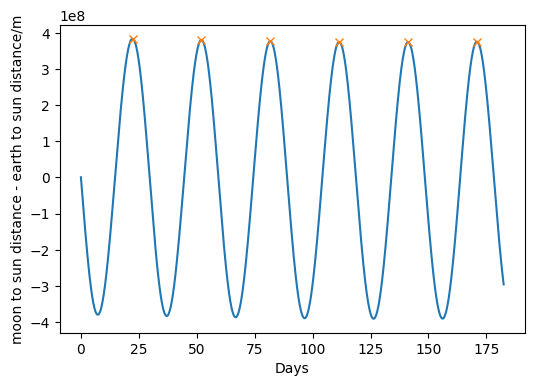

In [7]:
distance = np.zeros([3*365*24,1]) # store distance values
position =  position_update(r[0], r[1], r[2], m[0],m[1], m[2],v[0], v[1], v[2], position) 

# difference between Moon to Sun - Earth to Sun distance
distance = ((np.linalg.norm(position[:, 0:2] - position[:, 4:], axis=1))-np.linalg.norm(position[:, 0:2] - position[:, 2:4], axis=1))
df_distance = pd.DataFrame(distance, columns=['distance'])

# to find the peak
from scipy.signal import find_peaks
peaks, _ = find_peaks(distance[:12*365].flatten(), height = 0) # find peaks

#plotting
fig, ax = plt.subplots(figsize = (6,4))

# convert hours into days in x axes
tick_hour = np.arange(0, 12*365+1, 24*25)
tick_days = (tick_hour/24).astype(int)

ax.plot(df_distance.index[:12*365], df_distance['distance'][:12*365]) # plot the distance data
ax.plot(peaks, distance[peaks], "x") # plot the peaks
plt.xticks(tick_hour, tick_days)
ax.set_xlabel('Days')
ax.set_ylabel('moon to sun distance - earth to sun distance/m')

In [8]:
period = [] # store orbital period 
distance = ((np.linalg.norm(position[:, 0:2] - position[:, 4:], axis=1))-np.linalg.norm(position[:, 0:2] - position[:, 2:4], axis=1))
total = 0
for i in range(0,3):
    peaks, _ = find_peaks(distance[i*24*365:(i+1)*24*365].flatten(), height = 0)
    total += (sum(peaks[1:] - peaks[:-1]) / (len(peaks)-1)/ 24) # peaks[1:] - peaks[:-1] calculate the interval time, 24 hour = 1 day
average = total / 3
period.append(average)
print('The period of the Moon:', period[0],'days')

The period of the Moon: 29.73895202020202 days


# Start Changing the mass of the Sun and the Moon

when sun mass is 0. 7 sun mass
when sun mass is 0. 8 sun mass
when sun mass is 0. 9 sun mass
when sun mass is 0. 10 sun mass
when sun mass is 0. 11 sun mass
when sun mass is 0. 12 sun mass
when sun mass is 0. 13 sun mass


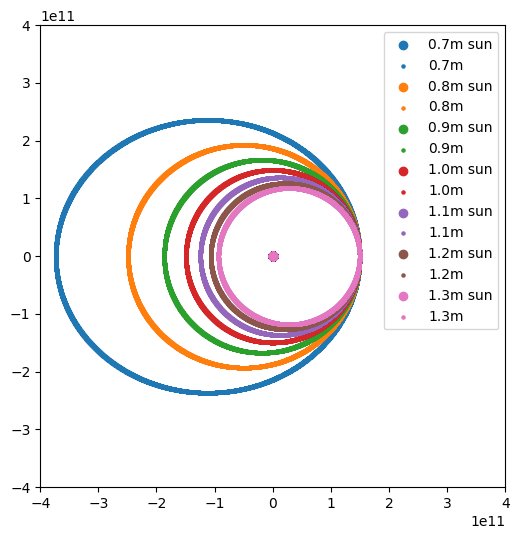

In [10]:

#  when the Sun between 0.7 and 1.3 solar masses
eccentricity = np.zeros([3, 7])
k = 0
fig, ax = plt.subplots(figsize =(6, 6))
labels = ['0.7m', '0.8m', '0.9m', '1.0m', '1.1m', '1.2m', '1.3m'] # to be used as labels for different masses

# because value set in range only can be integer, thus using '*0.1' in 'x*m[0]*0.1'
for x in range(7, 14):
    
    position =  position_update(r[0], r[1], r[2], x*m[0]*0.1, m[1], m[2], v[0], v[1], v[2], position) 
    # the Earth orbit around the Sun
    ax.scatter(position[:,0], position[:,1], label = labels[k] + ' sun') # sun position
    ax.scatter(position[:,2], position[:,3], c = f'C{k}', label = labels[k], s = 5)
    ax.set_xlim(-4*1e11, 4*1e11)
    ax.set_ylim(-4*1e11, 4*1e11) 

    distance_es = np.linalg.norm(position[:, 0:2]-position[:, 2:4], axis = 1) # to calculate distance 
    
    print("when sun mass is 0.", f'{x}', "sun mass") 
    # to find the max and min distance and calculate eccentricity, year by year
    for i in range(0, 3):
        max_value =(distance_es[24*i*365 : 24*(i+1)*365]).max()
        min_value =(distance_es[24*i*365 : 24*(i+1)*365]).min()
        e = (max_value-min_value)/(max_value+min_value)
        eccentricity[i, k] = e
    k += 1
ax.legend()
plt.show()
eccentricity_df = pd.DataFrame(eccentricity, columns = ['0.7m', '0.8m', '0.9m', '1.0m', '1.1m', '1.2m', '1.3m'], index = ['first year', 'second year', 'third year'])

In [11]:
eccentricity_df

,0.7m,0.8m,0.9m,1.0m,1.1m,1.2m,1.3m
first year,0.404303,0.249554,0.110710,0.001178,0.091242,0.166945,0.231072
second year,0.079349,0.241722,0.110726,0.001186,0.091241,0.166995,0.231064
third year,0.360945,0.150166,0.104410,0.001178,0.091240,0.166992,0.231056


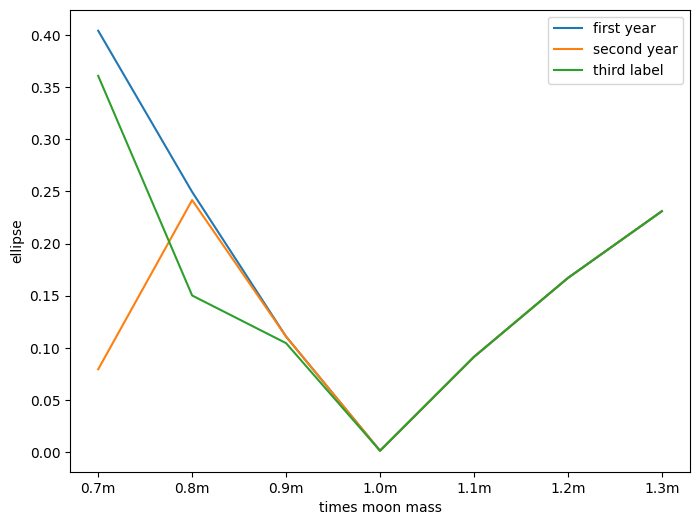

In [12]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (8, 6))
ax.plot(eccentricity_df.columns, eccentricity_df.loc['first year'], label='first year')
ax.plot(eccentricity_df.columns, eccentricity_df.loc['second year'], label = 'second year')
ax.plot(eccentricity_df.columns, eccentricity_df.loc['third year'], label = 'third label')
ax.set_xlabel('times moon mass')
ax.set_ylabel('ellipse')
ax.legend()
plt.show()

To find the orbital period when changing the mass of the Moon between 1 and 100 lunar masses
create a variable 'period', a list,  to store the average orbital period.

In [13]:
period = [] # store orbital period 
# calculate the orbital period of the Moon when its mass changing between 1 and 100 
for x in range(1, 101):
    position =  position_update(r[0], r[1], r[2], m[0],m[1], x*m[2], v[0], v[1], v[2], position) 
    distance = ((np.linalg.norm(position[:, 0:2] - position[:, 4:], axis=1))-np.linalg.norm(position[:, 0:2] - position[:, 2:4], axis=1)) # obtain distance value
    total = 0
    # to find the peaks in every year and  calculate the average
    for i in range(0,3):
        peaks, _ = find_peaks(distance[i*24*365:(i+1)*24*365].flatten(), height = 0)
        total += (sum(peaks[1:] -peaks[:-1]) / (len(peaks)-1)/ 24) # calculate average orbital period  24 hour = 1 day
    average = total / 3
    period.append(average)

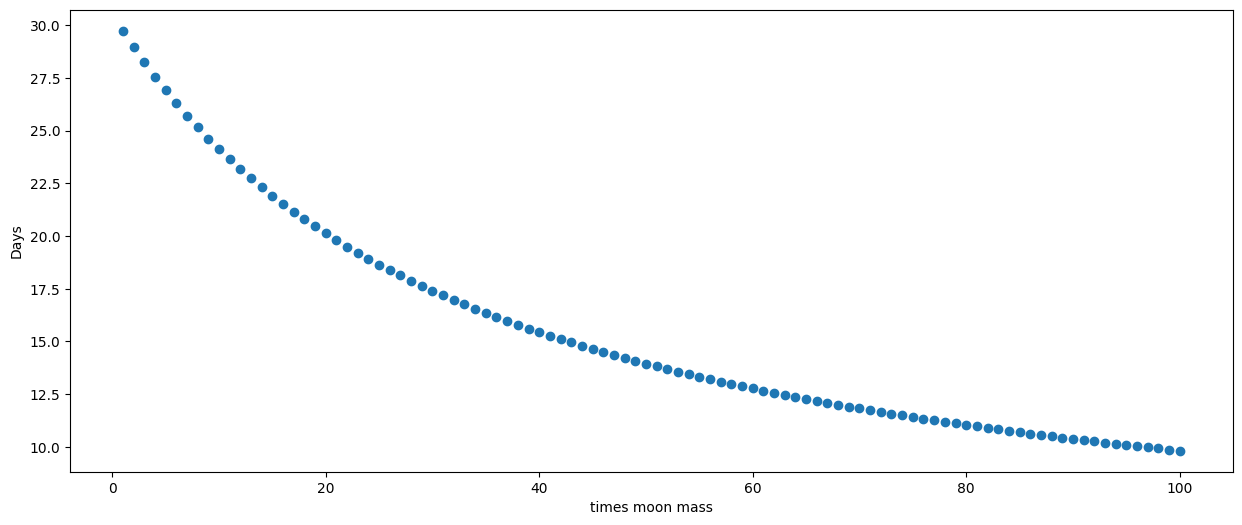

The maximum orbit period: 29.73895202020202
The minimum orbit period: 9.818287037037036


In [14]:
#plotting
period = np.array(period)
fig, ax = plt.subplots(figsize = (15, 6))
ax.scatter(np.arange(1, 101, 1), period)
ax.set_xlabel('times moon mass')
ax.set_ylabel('Days')
plt.show()

print("The maximum orbit period:", period.max())
print("The minimum orbit period:", period.min())

# Additional attempt- Finding the Full Moon Days in a year
Set the Earth as centre, when the Earth is between  of the Sun and the Moon ->  Full Moon

In this situation, 3 planets are nearly in a straight line:
                Sun ------ Earth------Moon
which means the angle between the vector Earth-Sun and the vector Earth-Moon is around 180 degrees but has a slightly shift

from : https://en.wikipedia.org/wiki/Full_moon#:~:text=The%20full%20moon%20is%20the,occurs%20roughly%20once%20a%20month.

Below, the full moon days of the first year with provided initial values of position, velocity and mass are calculated

In [15]:
position =  position_update(r[0], r[1], r[2], m[0],m[1],m[2],v[0],v[1],v[2],position) 

The full Moon Days are: [ 22.  52.  81. 111. 141. 170. 200. 230. 260. 289. 319. 349.]


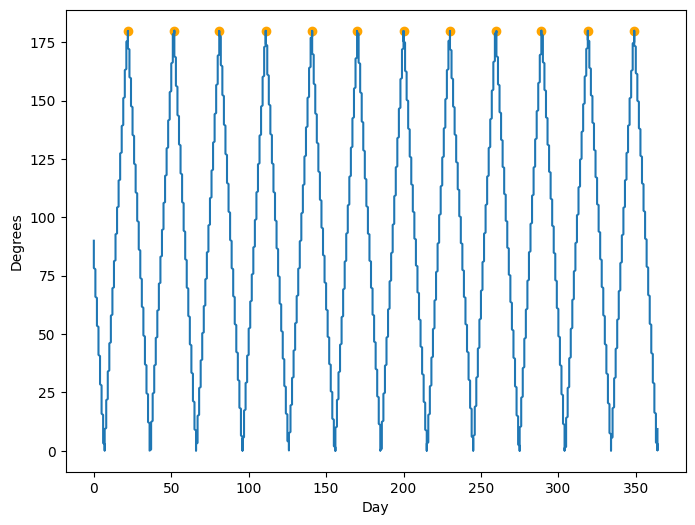

In [16]:
import matplotlib.pyplot as plt
combined= np.zeros([3*365*24, 3, 2])
# position is an ndarray with separate x, yvalues
# combined ndarray is used to put the xy value together
combined[:, 0, :] = position[:, :2]
combined[:, 1, :] = position[:, 2:4]
combined[:, 2, :] = position[:, 4:]

S = combined[:, 0] # sun vetors
E = combined[:, 1] # earth vectors
M = combined[:, 2] # Moon vectoors

SE = S-E
ME = M-E

theta_data = np.zeros([1*365*24, 2]) # to store the theta values
fig, ax = plt.subplots(figsize = (8,6))

for i in range(0, 1*365*24):
    cos_theta = (SE[i]@ ME[i])/(np.linalg.norm(SE[i])*np.linalg.norm(ME[i]))
    theta = np.degrees(np.arccos(cos_theta)) # to obrain the theta value and convert into degrees 
    # will be used later to draw the plot 
    theta_data[i, 0] = int(i/24)
    theta_data[i, 1] = theta 
    
from scipy.signal import find_peaks
peaks, _ = find_peaks( theta_data[:,1].flatten(), height = 0) # find peaks -> full moon day
print("The full Moon Days are:", theta_data[peaks][:,0])

ax.scatter(theta_data[peaks][:, 0],theta_data[peaks][:, 1], color = 'orange')# plot the  full moon day point
ax.plot(theta_data[:,0], theta_data[:,1]) # plot degree changes in a year
ax.set_xlabel('Day')
ax.set_ylabel('Degrees')

plt.show()

In [17]:
#print(theta_data[peaks][1:,0])
#print(theta_data[peaks][:-1,0])
#print(theta_data[peaks][1:,0]-theta_data[peaks][:-1,0])

In [18]:
print("A full moon occurs every", np.average(theta_data[peaks][1:,0]-theta_data[peaks][:-1,0]), "days on average")

A full moon occurs every 29.727272727272727 days on average
